In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import datetime
import warnings
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

# Teams

In [2]:
home= "Napoli"
away= "Inter"

In [3]:
df_home= pd.read_csv(f"../Data/{home}.csv")
df_home["Date"] = pd.to_datetime(df_home["Date"]) 
df_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
21,Napoli,Juventus,2025-01-25,W,H,2,1,1,49,1,...,1.4,1.7,-0.3,-0.5,-0.4,0.12,1,1.1,0.56,0.1
22,Napoli,Roma,2025-02-02,D,A,1,1,0,49,0,...,0.1,0.5,0.6,0.6,0.9,0.07,0,0.7,0.34,-0.3
23,Napoli,Udinese,2025-02-09,D,H,1,1,0,62,0,...,0.7,1.0,-0.1,-0.1,0.3,0.06,1,0.5,0.12,-0.5
24,Napoli,Lazio,2025-02-15,D,A,2,2,0,47,0,...,0.3,0.4,0.7,0.7,0.7,0.06,0,1.4,0.29,-0.6
25,Napoli,Como,2025-02-23,L,A,1,2,-1,58,0,...,0.8,0.5,-0.2,-0.2,-0.8,0.10,1,1.4,0.47,0.4


In [4]:
df_vs_home= pd.read_csv(f"../Data/vs {home}.csv")
df_vs_home["Date"] = pd.to_datetime(df_vs_home["Date"]) 
df_vs_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
21,Juventus,Napoli,2025-01-25,L,A,1,2,-1,51,0,...,0.4,0.2,0.2,0.2,-0.4,0.16,0,2.0,0.42,0.0
22,Roma,Napoli,2025-02-02,D,H,1,1,0,51,0,...,0.2,0.4,0.5,0.5,0.8,0.04,2,0.2,0.11,-0.8
23,Udinese,Napoli,2025-02-09,D,A,1,1,0,38,0,...,0.8,1.0,0.2,0.2,0.2,0.10,0,0.8,0.21,-0.2
24,Lazio,Napoli,2025-02-15,D,H,2,2,0,53,0,...,0.4,0.3,1.3,1.3,0.6,0.06,2,0.1,0.04,-0.9
25,Como,Napoli,2025-02-23,W,H,2,1,1,42,0,...,0.6,0.5,0.3,0.3,0.4,0.09,0,0.6,0.16,-0.4


In [5]:
df_away= pd.read_csv(f"../Data/{away}.csv")
df_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
21,Inter,Milan,2025-02-02,D,A,1,1,0,63,0,...,1.3,2.9,-0.3,-0.3,-0.3,0.08,0,1.0,0.25,0.0
22,Inter,Fiorentina,2025-02-06,L,A,0,3,-3,71,0,...,0.4,0.9,-0.4,-0.4,-0.4,0.04,1,1.6,0.27,-1.4
23,Inter,Fiorentina,2025-02-10,W,H,2,1,1,62,0,...,2.0,1.6,-1.2,-1.2,-1.0,0.10,1,1.0,0.02,0.0
24,Inter,Juventus,2025-02-16,L,A,0,1,-1,58,0,...,1.7,1.2,-1.8,-1.8,-1.7,0.11,1,1.1,0.15,0.1
25,Inter,Genoa,2025-02-22,W,H,1,0,1,62,0,...,1.3,1.5,-0.5,-0.5,-0.3,0.09,0,1.1,0.53,1.1


In [6]:
df_vs_away= pd.read_csv(f"../Data/vs {away}.csv")
df_vs_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_vs_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
21,Milan,Inter,2025-02-02,D,H,1,1,0,37,0,...,0.3,0.4,0.4,0.4,-0.3,0.06,0,1.6,0.28,0.6
22,Fiorentina,Inter,2025-02-06,W,H,3,0,3,29,0,...,0.6,0.5,2.0,2.0,1.4,0.10,0,0.2,0.09,0.2
23,Fiorentina,Inter,2025-02-10,L,A,1,2,-1,38,1,...,0.2,0.3,0.1,-0.2,-0.2,0.04,1,2.2,0.27,1.2
24,Juventus,Inter,2025-02-16,W,H,1,0,1,42,0,...,1.2,0.6,-0.3,-0.3,-0.2,0.08,0,1.0,0.49,1.0
25,Genoa,Inter,2025-02-22,L,A,0,1,-1,38,0,...,0.8,0.9,-1.3,-1.3,-0.8,0.12,0,1.8,0.45,0.8


In [7]:
print(list(df_away.columns))

['Team', 'Opp', 'Date', 'Result', 'H/A', 'GF', 'GA', 'GD', 'Poss', 'PKatt', 'G-PK', 'PK', 'PKm', 'Att (GK)', 'Thr', 'Pa Launch%', 'Pa AvgLen', 'Won', 'Lost', 'Won%', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 'PrgC', 'Last3rd Car', 'OppCr', 'Stp', 'Stp%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'GK Att', 'Launch%', 'AvgLen', 'Sh', 'G/Sh', 'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'PKcon', 'OG', 'Recov', '#OPA', 'AvgDist', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'PKdef', 'PKA', 'PKms', 'Missed PK%', 'PKAg', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassL

# Desc

# Features

## Offense

In [8]:
offense= ['G-PK', 'PK', 'PKm', 'Poss', 'PKatt', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 
          'PrgC', 'Last3rd Car', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'Sh', 'G/Sh', 
          'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 
          'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 
          'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 
          'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassLive Sc', 'PassDead Sc', 'TO Sc', 'Sh-Sh', 
          'Fld Sc', 'Def-Sc', 'Touches', 'Def Pen', 'Tch Def 3rd', 'Tch Mid 3rd', 'Tch Att 3rd', 'Att Pen', 'Live Tch', 'xG', 
          'npxG', 'xGD', 'npxGD', 'xAG', 'xA', 'G-xG', 'np:G-xG', 'A-xAG', 'npxG/Sh', 'FKAtt', 'GF']

In [9]:
df_home_off= df_home[offense]
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
21,1,1,0,49,1,14,8,57.1,3,21.4,...,1.5,0.7,1.4,1.7,-0.3,-0.5,-0.4,0.12,1,2
22,1,0,0,49,0,12,5,41.7,6,50.0,...,-0.2,-0.2,0.1,0.5,0.6,0.6,0.9,0.07,0,1
23,1,0,0,62,0,8,2,25.0,6,75.0,...,0.3,0.3,0.7,1.0,-0.1,-0.1,0.3,0.06,1,1
24,1,0,0,47,0,3,1,33.3,1,33.3,...,-0.4,-0.4,0.3,0.4,0.7,0.7,0.7,0.06,0,2
25,1,0,0,58,0,25,9,36.0,12,48.0,...,0.5,0.5,0.8,0.5,-0.2,-0.2,-0.8,0.10,1,1


In [10]:
df_vs_home_off= df_vs_home[offense]
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
21,1,0,0,51,0,14,6,42.9,6,42.9,...,-1.5,-0.7,0.4,0.2,0.2,0.2,-0.4,0.16,0,1
22,1,0,0,51,0,9,3,33.3,5,55.6,...,0.2,0.2,0.2,0.4,0.5,0.5,0.8,0.04,2,1
23,1,0,0,38,0,11,7,63.6,2,18.2,...,-0.3,-0.3,0.8,1.0,0.2,0.2,0.2,0.10,0,1
24,2,0,0,53,0,20,10,50.0,10,50.0,...,0.4,0.4,0.4,0.3,1.3,1.3,0.6,0.06,2,2
25,1,0,0,42,0,22,8,36.4,9,40.9,...,-0.5,-0.5,0.6,0.5,0.3,0.3,0.4,0.09,0,2


In [11]:
df_away_off= df_away[offense]
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
21,1,0,0,63,0,12,6,50.0,6,50.0,...,0.7,0.7,1.3,2.9,-0.3,-0.3,-0.3,0.08,0,1
22,0,0,0,71,0,7,3,42.9,2,28.6,...,-0.6,-0.6,0.4,0.9,-0.4,-0.4,-0.4,0.04,1,0
23,1,0,0,62,0,13,5,38.5,6,46.2,...,1.3,2.0,2.0,1.6,-1.2,-1.2,-1.0,0.10,1,2
24,0,0,0,58,0,14,6,42.9,7,50.0,...,0.4,0.4,1.7,1.2,-1.8,-1.8,-1.7,0.11,1,0
25,1,0,0,62,0,13,5,38.5,5,38.5,...,0.2,0.2,1.3,1.5,-0.5,-0.5,-0.3,0.09,0,1


In [12]:
df_vs_away_off= df_vs_away[offense]
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
21,1,0,0,37,0,12,5,41.7,7,58.3,...,-0.7,-0.7,0.3,0.4,0.4,0.4,-0.3,0.06,0,1
22,3,0,0,29,0,15,6,40.0,8,53.3,...,0.6,0.6,0.6,0.5,2.0,2.0,1.4,0.10,0,3
23,0,1,0,38,1,11,2,18.2,8,72.7,...,-1.3,-2.0,0.2,0.3,0.1,-0.2,-0.2,0.04,1,1
24,1,0,0,42,0,19,7,36.8,12,63.2,...,-0.4,-0.4,1.2,0.6,-0.3,-0.3,-0.2,0.08,0,1
25,0,0,0,38,0,9,6,66.7,2,22.2,...,-0.2,-0.2,0.8,0.9,-1.3,-1.3,-0.8,0.12,0,0


## Defence

In [13]:
defence= ['OppCr', 'Stp', 'Stp%', 'PKcon', '#OPA', 'AvgDist', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'SoTA', 'Saves', 
          'Save%', 'Tkl', 'TklW', 'Tkl Def 3rd', 'Tkl Mid 3rd', 'Tkl Att 3rd', 'Tkl.2', 'Tkl Att', 'Tkl%', 'Lost Tkl', 
          'Ints', 'BlcSh', 'Pass', 'Int', 'Tkl+Int', 'Clr', 'Err',  'PSxG', 'PSxG/SoT', 'PSxG+/-', 'GA']

In [14]:
df_home_def= df_home[defence]
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
21,5,0,0.0,0,0,10.2,0,NaN,0,0,...,0,3,8,22,17,1,1.1,0.56,0.1,1
22,18,1,5.6,0,1,15.3,0,NaN,0,0,...,5,2,6,21,30,0,0.7,0.34,-0.3,1
23,12,1,8.3,0,1,15.0,0,NaN,0,0,...,1,9,4,9,14,0,0.5,0.12,-0.5,1
24,19,0,0.0,0,0,16.0,0,NaN,0,0,...,1,1,7,25,27,2,1.4,0.29,-0.6,2
25,7,0,0.0,0,3,20.5,0,NaN,0,0,...,4,8,7,25,16,2,1.4,0.47,0.4,2


In [15]:
df_vs_home_def= df_vs_home[defence]
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
21,17,1,5.9,1,0,4.0,0,0.0,0,0,...,6,4,7,23,22,0,2.0,0.42,0.0,2
22,8,1,12.5,0,0,10.8,0,NaN,0,0,...,1,7,4,13,17,1,0.2,0.11,-0.8,1
23,14,1,7.1,0,0,6.5,0,NaN,0,1,...,10,8,6,19,26,0,0.8,0.21,-0.2,1
24,7,0,0.0,0,0,NaN,0,NaN,0,0,...,2,7,13,20,11,0,0.1,0.04,-0.9,2
25,14,1,7.1,0,6,17.6,0,NaN,0,0,...,4,10,5,31,36,2,0.6,0.16,-0.4,1


In [16]:
df_away_def= df_away[defence]
df_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,11,0,0.0,1,1,21.5,1,100.0,0,0,...,1,4,3,14,17,1,2.1,0.16,0.1,2
1,12,1,8.3,0,1,13.2,0,NaN,0,0,...,2,2,6,20,16,0,0.4,0.11,0.4,0
2,13,1,7.7,0,0,7.3,0,NaN,0,0,...,4,6,3,20,21,0,0.1,0.12,0.1,0
3,11,0,0.0,0,0,11.5,0,NaN,0,0,...,1,5,4,19,9,0,0.6,0.31,-0.4,1
4,6,0,0.0,0,0,13.4,0,NaN,0,0,...,3,6,7,18,18,0,2.4,0.30,0.4,2


In [17]:
df_vs_away_def= df_vs_away[defence]
df_vs_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,17,1,5.9,0,0,4.0,0,NaN,0,0,...,3,6,12,22,22,1,2.9,0.41,0.9,2
1,18,1,5.6,1,0,5.9,0,0.0,0,0,...,3,10,3,14,22,0,1.8,0.31,-0.2,2
2,7,0,0.0,0,1,35.0,0,NaN,0,1,...,4,3,5,18,11,1,1.9,0.49,-1.1,4
3,21,0,0.0,0,0,5.0,0,NaN,0,0,...,4,5,12,25,31,1,0.9,0.44,-0.1,1
4,18,1,5.6,0,0,11.5,0,NaN,0,0,...,5,6,10,20,18,0,1.0,0.26,0.0,1


## Combined

In [18]:
combined= ['Won', 'Lost', 'Won%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'Recov']

In [19]:
df_home_cmb= df_home[combined]
df_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
21,17,8,68.0,2,0,0,9,15,33
22,15,14,51.7,1,0,0,13,7,33
23,11,7,61.1,0,0,0,11,9,37
24,11,12,47.8,2,0,0,19,8,36
25,13,17,43.3,3,0,0,14,17,40


In [20]:
df_vs_home_cmb= df_vs_home[combined]
df_vs_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
21,8,17,32.0,2,0,0,15,9,40
22,14,15,48.3,2,0,0,9,10,38
23,7,11,38.9,1,0,0,10,11,40
24,12,11,52.2,2,0,0,9,17,38
25,17,13,56.7,1,0,0,17,14,45


In [21]:
df_away_cmb= df_away[combined]
df_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
21,13,15,46.4,2,0,0,9,4,41
22,22,15,59.5,0,0,0,10,11,33
23,21,9,70.0,4,0,0,16,15,36
24,15,13,53.6,1,0,0,10,17,32
25,35,17,67.3,0,0,0,7,14,47


In [22]:
df_vs_away_cmb= df_vs_away[combined]
df_vs_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
21,15,13,53.6,0,0,0,5,7,30
22,15,22,40.5,1,0,0,11,9,34
23,9,21,30.0,3,0,0,15,15,28
24,13,15,46.4,1,0,0,17,10,38
25,17,35,32.7,2,0,0,14,6,49


## By Team

In [23]:
def create_lagged_features(df, target_cols, window= 4):
    """
    Creates lagged and rolling window features for a given dataset.
    
    Parameters:
    df (pd.DataFrame): The input dataframe containing game-by-game data.
    team_col (str): The column name representing the team.
    date_col (str): The column name representing the game date.
    target_cols (list): List of columns to create lagged and rolling features for.
    opponent_col (str, optional): Column representing the opponent team (if applicable).
    lags (list): List of lag periods to include.
    rolling_windows (list): List of rolling window sizes for moving averages and std dev.
    
    Returns:
    pd.DataFrame: Dataframe with additional lagged and rolling features.
    """
    df = df.copy()
    
    
    # Create lagged features for the given columns
    #for col in target_cols:
     #   for lag in range(1, window+1):
      #      df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    
    # Create rolling window features (mean & std)
    for col in target_cols:
        df[f'{col}_rolling_avg_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).mean()
        df[f'{col}_rolling_std_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).std()
    
    # Fill NA values (after shifting to avoid data leakage)
    df = df.fillna(0)
    
    return df


In [24]:
df_home_off= create_lagged_features(df_home_off, offense)
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
21,1,1,0,49,1,14,8,57.1,3,21.4,...,0.775,1.144188,0.225,0.830161,0.0875,0.033040,0.00,0.00000,2.25,0.957427
22,1,0,0,49,0,12,5,41.7,6,50.0,...,0.700,1.235584,0.300,0.725718,0.1050,0.023805,0.25,0.50000,2.50,0.577350
23,1,0,0,62,0,8,2,25.0,6,75.0,...,0.550,1.190238,0.450,0.785281,0.1000,0.029439,0.25,0.50000,2.00,0.816497
24,1,0,0,47,0,3,1,33.3,1,33.3,...,0.550,1.190238,0.525,0.741058,0.0950,0.035119,0.50,0.57735,1.75,0.957427
25,1,0,0,58,0,25,9,36.0,12,48.0,...,0.175,0.573730,0.375,0.573730,0.0775,0.028723,0.50,0.57735,1.50,0.577350


In [25]:
df_vs_home_off= create_lagged_features(df_vs_home_off, offense)
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
21,1,0,0,51,0,14,6,42.9,6,42.9,...,-0.050,0.967815,-0.375,0.206155,0.0550,0.017321,0.25,0.500000,0.50,1.000000
22,1,0,0,51,0,9,3,33.3,5,55.6,...,0.050,0.967815,-0.425,0.170783,0.0825,0.054391,0.00,0.000000,0.75,0.957427
23,1,0,0,38,0,11,7,63.6,2,18.2,...,0.425,0.670199,-0.075,0.596518,0.0725,0.058523,0.50,1.000000,1.00,0.816497
24,2,0,0,53,0,20,10,50.0,10,50.0,...,0.550,0.519615,0.025,0.602080,0.0875,0.055000,0.50,1.000000,1.25,0.500000
25,1,0,0,42,0,22,8,36.4,9,40.9,...,0.550,0.519615,0.300,0.529150,0.0900,0.052915,1.00,1.154701,1.25,0.500000


In [26]:
df_away_def= create_lagged_features(df_away_def, defence)
df_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
21,6,0,0.0,0,0,9.0,0,0.0,0,0,...,0.75,1.5,0.750,0.506623,0.3000,0.248596,-5.551115e-17,0.898146,0.75,0.957427
22,6,0,0.0,0,1,30.0,0,0.0,0,1,...,0.75,1.5,0.975,0.262996,0.3475,0.201060,-2.500000e-02,0.895824,1.00,0.816497
23,12,0,0.0,1,0,0.0,0,0.0,0,0,...,0.25,0.5,1.100,0.416333,0.3675,0.183371,-1.500000e-01,1.075484,1.25,1.258306
24,14,0,0.0,0,1,15.3,0,0.0,0,0,...,0.25,0.5,1.200,0.282843,0.2125,0.130735,-5.000000e-02,1.063015,1.25,1.258306
25,20,1,5.0,0,1,23.5,0,0.0,0,0,...,0.25,0.5,1.175,0.287228,0.1725,0.114419,-3.250000e-01,0.718215,1.50,1.000000


In [27]:
df_vs_away_def= create_lagged_features(df_vs_away_def, defence)
df_vs_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
21,25,0,0.0,0,2,26.0,0,0.0,0,0,...,1.00,0.816497,2.150,0.810350,0.3425,0.099121,-0.350,0.925563,2.50,1.290994
22,18,0,0.0,0,0,8.0,0,0.0,0,0,...,1.00,0.816497,2.050,0.858293,0.3250,0.103441,-0.450,0.732575,2.50,1.290994
23,23,0,0.0,0,0,7.0,0,0.0,0,0,...,0.75,0.957427,1.750,1.271482,0.2800,0.159374,-0.250,0.785281,2.00,1.825742
24,14,1,7.1,0,1,14.7,0,0.0,0,0,...,0.75,0.957427,1.825,1.291962,0.2800,0.159374,0.325,0.797392,1.75,1.707825
25,17,2,11.8,0,0,6.3,0,0.0,0,1,...,0.25,0.500000,1.250,0.854400,0.2825,0.163580,0.750,0.443471,0.75,0.957427


In [28]:
df_away_off= create_lagged_features(df_away_off, offense)
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
21,1,0,0,63,0,12,6,50.0,6,50.0,...,0.500,1.095445,0.775,1.504161,0.1350,0.030000,0.75,0.957427,2.50,1.290994
22,0,0,0,71,0,7,3,42.9,2,28.6,...,0.650,0.854400,0.950,1.247664,0.1275,0.040311,0.25,0.500000,2.50,1.290994
23,1,0,0,62,0,13,5,38.5,6,46.2,...,0.475,1.007886,0.825,1.379311,0.1000,0.054772,0.25,0.500000,2.00,1.825742
24,0,0,0,58,0,14,6,42.9,7,50.0,...,-0.050,1.234234,0.150,1.466288,0.0975,0.054391,0.50,0.577350,1.75,1.707825
25,1,0,0,62,0,13,5,38.5,5,38.5,...,-0.925,0.708872,-0.850,0.645497,0.0825,0.030957,0.75,0.500000,0.75,0.957427


In [29]:
df_vs_away_off= create_lagged_features(df_vs_away_off, offense)
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
21,1,0,0,37,0,12,5,41.7,7,58.3,...,0.175,1.027538,0.325,1.034005,0.0575,0.009574,0.75,0.50000,0.75,0.957427
22,3,0,0,29,0,15,6,40.0,8,53.3,...,0.375,0.953502,0.325,1.034005,0.0575,0.009574,0.50,0.57735,1.00,0.816497
23,0,1,0,38,1,11,2,18.2,8,72.7,...,0.525,1.187083,0.275,0.953502,0.0700,0.021602,0.25,0.50000,1.25,1.258306
24,1,0,0,42,0,19,7,36.8,12,63.2,...,0.325,1.236595,0.050,0.925563,0.0625,0.026300,0.25,0.50000,1.25,1.258306
25,0,0,0,38,0,9,6,66.7,2,22.2,...,0.475,1.062623,0.175,0.818026,0.0700,0.025820,0.25,0.50000,1.50,1.000000


In [30]:
df_home_def= create_lagged_features(df_home_def, defence)
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
21,5,0,0.0,0,0,10.2,0,0.0,0,0,...,0.00,0.000000,0.925,1.123610,0.2475,0.144539,0.425,0.170783,0.50,1.000000
22,18,1,5.6,0,1,15.3,0,0.0,0,0,...,0.25,0.500000,1.100,1.067708,0.3325,0.208706,0.350,0.238048,0.75,0.957427
23,12,1,8.3,0,1,15.0,0,0.0,0,0,...,0.25,0.500000,1.150,1.034408,0.3575,0.199729,0.150,0.369685,1.00,0.816497
24,19,0,0.0,0,0,16.0,0,0.0,0,0,...,0.25,0.500000,1.225,0.950000,0.3650,0.186458,-0.025,0.485627,1.25,0.500000
25,7,0,0.0,0,3,20.5,0,0.0,0,0,...,0.75,0.957427,0.925,0.403113,0.3275,0.181361,-0.325,0.309570,1.25,0.500000


In [31]:
df_vs_home_def= create_lagged_features(df_vs_home_def, defence)
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
21,17,1,5.9,1,0,4.0,0,0.0,0,0,...,1.25,0.50000,1.350,0.741620,0.2475,0.160909,-0.650,1.161895,2.25,0.957427
22,8,1,12.5,0,0,10.8,0,0.0,0,0,...,0.75,0.50000,1.350,0.741620,0.3150,0.162993,-0.900,0.707107,2.50,0.577350
23,14,1,7.1,0,0,6.5,0,0.0,0,1,...,0.75,0.50000,0.975,0.873212,0.2850,0.192267,-0.775,0.655108,2.00,0.816497
24,7,0,0.0,0,0,0.0,0,0.0,0,0,...,0.50,0.57735,1.100,0.774597,0.3050,0.174069,-0.650,0.718795,1.75,0.957427
25,14,1,7.1,0,6,17.6,0,0.0,0,0,...,0.25,0.50000,0.775,0.873212,0.1950,0.165429,-0.475,0.442531,1.50,0.577350


In [32]:
df_home_cmb.rename(columns= {col: f"h_{col}" for col in df_home_cmb.columns}, inplace= True)
df_home_cmb= create_lagged_features(df_home_cmb, df_home_cmb.columns)
df_home_cmb.tail()

,h_Won,h_Lost,h_Won%,h_CrdY,h_CrdR,h_2CrdY,h_Fls,h_Fld,h_Recov,h_Won_rolling_avg_4,...,h_CrdR_rolling_avg_4,h_CrdR_rolling_std_4,h_2CrdY_rolling_avg_4,h_2CrdY_rolling_std_4,h_Fls_rolling_avg_4,h_Fls_rolling_std_4,h_Fld_rolling_avg_4,h_Fld_rolling_std_4,h_Recov_rolling_avg_4,h_Recov_rolling_std_4
21,17,8,68.0,2,0,0,9,15,33,15.00,...,0.0,0.0,0.0,0.0,10.00,3.741657,11.75,5.909033,44.00,1.825742
22,15,14,51.7,1,0,0,13,7,33,15.00,...,0.0,0.0,0.0,0.0,9.75,3.774917,12.75,6.075909,41.00,5.597619
23,11,7,61.1,0,0,0,11,9,37,14.00,...,0.0,0.0,0.0,0.0,9.25,2.872281,11.00,6.582806,38.75,6.751543
24,11,12,47.8,2,0,0,19,8,36,14.25,...,0.0,0.0,0.0,0.0,10.50,1.914854,12.25,5.123475,36.50,4.725816
25,13,17,43.3,3,0,0,14,17,40,13.50,...,0.0,0.0,0.0,0.0,13.00,4.320494,9.75,3.593976,34.75,2.061553


In [33]:
df_vs_home_cmb.rename(columns= {col: f"vh_{col}" for col in df_vs_home_cmb.columns}, inplace= True)
df_vs_home_cmb= create_lagged_features(df_vs_home_cmb, df_vs_home_cmb.columns)
df_vs_home_cmb.tail()

,vh_Won,vh_Lost,vh_Won%,vh_CrdY,vh_CrdR,vh_2CrdY,vh_Fls,vh_Fld,vh_Recov,vh_Won_rolling_avg_4,...,vh_CrdR_rolling_avg_4,vh_CrdR_rolling_std_4,vh_2CrdY_rolling_avg_4,vh_2CrdY_rolling_std_4,vh_Fls_rolling_avg_4,vh_Fls_rolling_std_4,vh_Fld_rolling_avg_4,vh_Fld_rolling_std_4,vh_Recov_rolling_avg_4,vh_Recov_rolling_std_4
21,8,17,32.0,2,0,0,15,9,40,13.00,...,0.0,0.0,0.0,0.0,13.00,5.944185,9.25,3.593976,43.50,7.681146
22,14,15,48.3,2,0,0,9,10,38,13.00,...,0.0,0.0,0.0,0.0,13.75,5.965177,9.00,3.559026,45.50,3.696846
23,7,11,38.9,1,0,0,10,11,40,13.75,...,0.0,0.0,0.0,0.0,11.75,5.852350,8.00,1.825742,43.25,4.991660
24,12,11,52.2,2,0,0,9,17,38,10.75,...,0.0,0.0,0.0,0.0,13.00,4.242641,9.25,1.707825,41.50,4.434712
25,17,13,56.7,1,0,0,17,14,45,10.25,...,0.0,0.0,0.0,0.0,10.75,2.872281,11.75,3.593976,39.00,1.154701


In [34]:
df_away_cmb.rename(columns= {col: f"va_{col}" for col in df_away_cmb.columns}, inplace= True)
df_away_cmb= create_lagged_features(df_away_cmb, df_away_cmb.columns)
df_away_cmb.tail()

,va_Won,va_Lost,va_Won%,va_CrdY,va_CrdR,va_2CrdY,va_Fls,va_Fld,va_Recov,va_Won_rolling_avg_4,...,va_CrdR_rolling_avg_4,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4
21,13,15,46.4,2,0,0,9,4,41,15.00,...,0.0,0.0,0.0,0.0,13.00,4.082483,10.75,2.061553,41.00,8.869423
22,22,15,59.5,0,0,0,10,11,33,14.75,...,0.0,0.0,0.0,0.0,12.50,4.509250,9.00,3.915780,38.25,5.315073
23,21,9,70.0,4,0,0,16,15,36,15.25,...,0.0,0.0,0.0,0.0,10.25,1.258306,9.00,3.915780,38.50,4.932883
24,15,13,53.6,1,0,0,10,17,32,16.00,...,0.0,0.0,0.0,0.0,11.75,3.095696,10.75,4.787136,36.50,3.316625
25,35,17,67.3,0,0,0,7,14,47,17.75,...,0.0,0.0,0.0,0.0,11.25,3.201562,11.75,5.737305,35.50,4.041452


In [35]:
df_vs_away_cmb.rename(columns= {col: f"a_{col}" for col in df_vs_away_cmb.columns}, inplace= True)
df_vs_away_cmb= create_lagged_features(df_vs_away_cmb, df_vs_away_cmb.columns)
df_vs_away_cmb.tail()

,a_Won,a_Lost,a_Won%,a_CrdY,a_CrdR,a_2CrdY,a_Fls,a_Fld,a_Recov,a_Won_rolling_avg_4,...,a_CrdR_rolling_avg_4,a_CrdR_rolling_std_4,a_2CrdY_rolling_avg_4,a_2CrdY_rolling_std_4,a_Fls_rolling_avg_4,a_Fls_rolling_std_4,a_Fld_rolling_avg_4,a_Fld_rolling_std_4,a_Recov_rolling_avg_4,a_Recov_rolling_std_4
21,15,13,53.6,0,0,0,5,7,30,10.00,...,0.0,0.0,0.0,0.0,11.75,1.892969,12.75,4.349329,37.75,2.753785
22,15,22,40.5,1,0,0,11,9,34,11.25,...,0.0,0.0,0.0,0.0,10.00,3.829708,11.75,5.251984,35.00,3.741657
23,9,21,30.0,3,0,0,15,15,28,12.50,...,0.0,0.0,0.0,0.0,9.50,3.415650,9.25,2.061553,34.50,3.696846
24,13,15,46.4,1,0,0,17,10,38,11.25,...,0.0,0.0,0.0,0.0,11.00,4.320494,10.75,3.500000,32.75,4.856267
25,17,35,32.7,2,0,0,14,6,49,13.00,...,0.0,0.0,0.0,0.0,12.00,5.291503,10.25,3.403430,32.50,4.434712


In [36]:
df_home_off.drop(columns=['GF'], inplace= True)
df_away_off.drop(columns=['GF'], inplace= True)
df_vs_home_off.drop(columns=['GF'], inplace= True)
df_vs_away_off.drop(columns=['GF'], inplace= True)

df_home_def.drop(columns=['GA'], inplace= True)
df_away_def.drop(columns=['GA'], inplace= True)
df_vs_home_def.drop(columns=['GA'], inplace= True)
df_vs_away_def.drop(columns=['GA'], inplace= True)

## Final DFs

In [37]:
df_home_frw= pd.concat([df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True), 
                        df_away_def[-1:].reset_index(drop=True),
                        ], 
                        axis= 1
                        )
#df_home_frw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_frw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_frw["H/A"]= "H"
df_home_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4,H/A
0,1,0,0,58,0,25,9,36.0,12,48.0,...,0.5,1.175,0.287228,0.1725,0.114419,-0.325,0.718215,1.5,1.0,H


In [38]:
df_home_gf= pd.concat([df_home_off[:-1], 
                       df_vs_home_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_home[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1
                       )
df_home_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,0,0,0,67,0,20,8,40.0,7,35.0,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,H,3
1,3,0,0,39,0,23,10,43.5,10,43.5,...,0.0,0.0,16.000000,0.000000,12.000000,0.000000,31.000000,0.000000,H,2
2,2,0,0,55,0,18,6,33.3,7,38.9,...,0.0,0.0,12.500000,4.949747,12.000000,0.000000,36.000000,7.071068,A,4
3,4,0,0,49,0,19,6,31.6,11,57.9,...,0.0,0.0,10.333333,5.131601,12.666667,1.154701,31.333333,9.504385,A,0
4,0,0,0,36,0,12,6,50.0,5,41.7,...,0.0,0.0,12.500000,6.027714,12.000000,1.632993,34.250000,9.708244,H,2


In [39]:
df_home_bcw= pd.concat([df_home_def[-1:].reset_index(drop=True), 
                        df_away_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_home_bcw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_bcw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_bcw["H/A"]= "H"
df_home_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,7,0,0.0,0,3,20.5,0,0.0,0,0,...,0.0,0.0,0.0,11.25,3.201562,11.75,5.737305,35.5,4.041452,H


In [40]:
df_home_ga= pd.concat([df_home_def[:-1], 
                       df_vs_home_off[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_home[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_home_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,5,1,20.0,0,2,21.2,0,0.0,0,0,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,H,0
1,14,0,0.0,0,1,23.0,0,0.0,0,0,...,0.0,0.0,16.000000,0.000000,12.000000,0.000000,31.000000,0.000000,H,1
2,5,0,0.0,1,0,16.0,0,0.0,0,0,...,0.0,0.0,12.500000,4.949747,12.000000,0.000000,36.000000,7.071068,A,0
3,21,0,0.0,0,0,0.0,0,0.0,0,0,...,0.0,0.0,10.333333,5.131601,12.666667,1.154701,31.333333,9.504385,A,0
4,13,2,15.4,0,0,4.5,0,0.0,0,0,...,0.0,0.0,12.500000,6.027714,12.000000,1.632993,34.250000,9.708244,H,0


In [41]:
df_away_frw= pd.concat([df_away_off[-1:].reset_index(drop=True), 
                        df_home_def[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_frw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_frw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_frw["H/A"]= "A"
df_away_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,1,0,0,62,0,13,5,38.5,5,38.5,...,0.0,0.0,0.0,11.25,3.201562,11.75,5.737305,35.5,4.041452,A


In [42]:
df_away_gf= pd.concat([df_away_off[:-1], 
                       df_vs_away_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_away[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,2,0,0,68,0,11,4,36.4,6,54.5,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,H,2
1,1,1,0,61,1,6,0,0.0,5,83.3,...,0.0,0.0,16.000000,0.000000,12.000000,0.000000,31.000000,0.000000,H,4
2,3,0,0,55,0,12,4,33.3,7,58.3,...,0.0,0.0,12.500000,4.949747,12.000000,0.000000,36.000000,7.071068,A,1
3,1,0,0,60,0,8,1,12.5,5,62.5,...,0.0,0.0,10.333333,5.131601,12.666667,1.154701,31.333333,9.504385,H,1
4,1,0,0,57,0,6,3,50.0,3,50.0,...,0.0,0.0,12.500000,6.027714,12.000000,1.632993,34.250000,9.708244,A,3


In [43]:
df_away_bcw= pd.concat([df_away_def[-1:].reset_index(drop=True), 
                        df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_bcw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_bcw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_bcw["H/A"]= "H"
df_away_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,20,1,5.0,0,1,23.5,0,0.0,0,0,...,0.0,0.0,0.0,11.25,3.201562,11.75,5.737305,35.5,4.041452,H


In [44]:
df_away_ga= pd.concat([df_away_def[:-1], 
                       df_vs_away_off[:-1],
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_away[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,11,0,0.0,1,1,21.5,1,100.0,0,0,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,H,0
1,12,1,8.3,0,1,13.2,0,0.0,0,0,...,0.0,0.0,16.000000,0.000000,12.000000,0.000000,31.000000,0.000000,H,0
2,13,1,7.7,0,0,7.3,0,0.0,0,0,...,0.0,0.0,12.500000,4.949747,12.000000,0.000000,36.000000,7.071068,A,1
3,11,0,0.0,0,0,11.5,0,0.0,0,0,...,0.0,0.0,10.333333,5.131601,12.666667,1.154701,31.333333,9.504385,H,2
4,6,0,0.0,0,0,13.4,0,0.0,0,0,...,0.0,0.0,12.500000,6.027714,12.000000,1.632993,34.250000,9.708244,A,2


In [45]:
df_home_gf = df_home_gf.fillna(0)

In [46]:
df_home_ga = df_home_ga.fillna(0)

In [47]:
df_away_ga = df_away_ga.fillna(0)

In [48]:
df_away_gf = df_away_gf.fillna(0)

# Categories

In [49]:
# Define bins for football goals classification
bins = [-1, 0, 1, 2, 3, float('inf')]  # -1 to include 0 as a bin
labels = [0, 1, 2, 3, 4]  # Assigning numeric class labels

# Apply binning
df_home_gf['GFC'] = pd.cut(df_home_gf['GF'], bins=bins, labels=labels)
df_away_gf['GFC'] = pd.cut(df_away_gf['GF'], bins=bins, labels=labels)
df_home_ga['GAC'] = pd.cut(df_home_ga['GA'], bins=bins, labels=labels)
df_away_ga['GAC'] = pd.cut(df_away_ga['GA'], bins=bins, labels=labels)

In [50]:
df_home_gf.drop(columns=['GF'], inplace= True)
df_away_gf.drop(columns=['GF'], inplace= True)

df_home_ga.drop(columns=['GA'], inplace= True)
df_away_ga.drop(columns=['GA'], inplace= True)


# Models

## Classification

### Model Home

In [51]:
target = "GFC"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [52]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [53]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

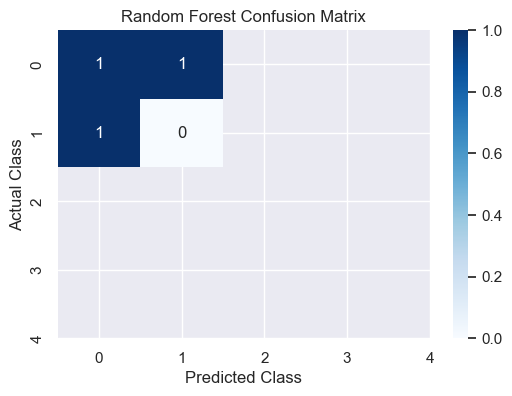

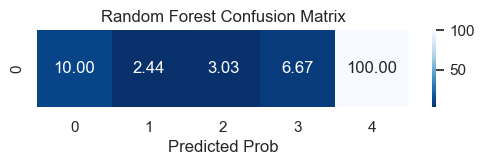

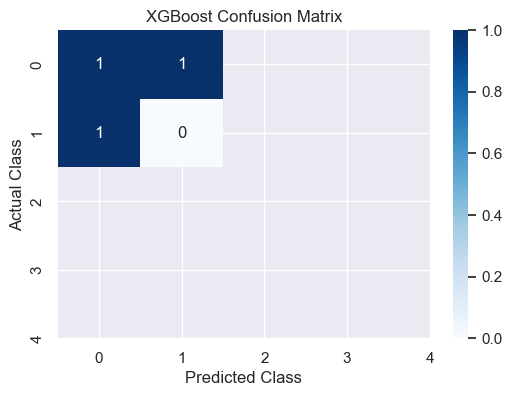

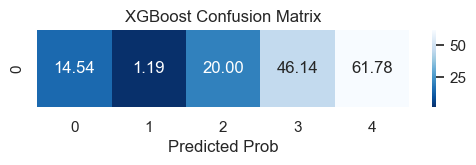

In [56]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(1/pred, annot=True, fmt='.2f', cmap='Blues_r', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Home

In [57]:
target = "GAC"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [58]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [59]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

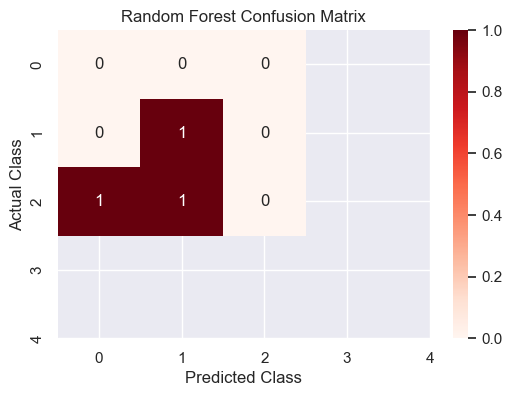

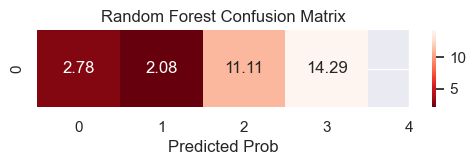

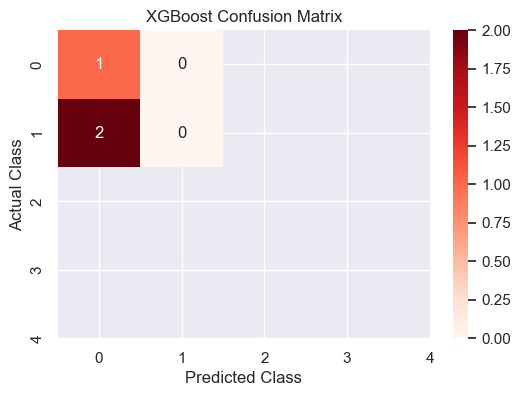

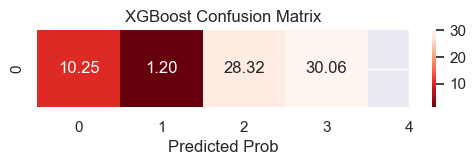

In [60]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(1/pred, annot=True, fmt='.2f', cmap='Reds_r', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model Away

In [61]:
target = "GFC"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [62]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [63]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

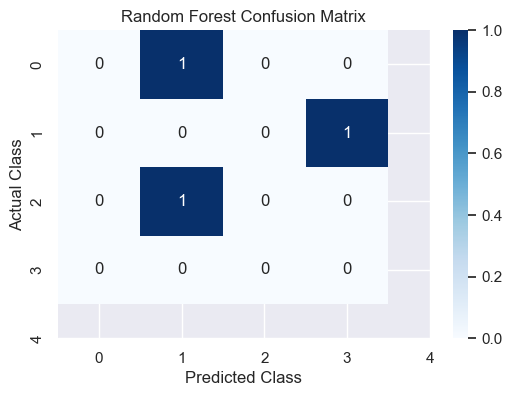

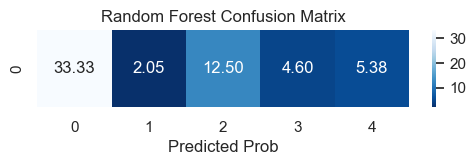

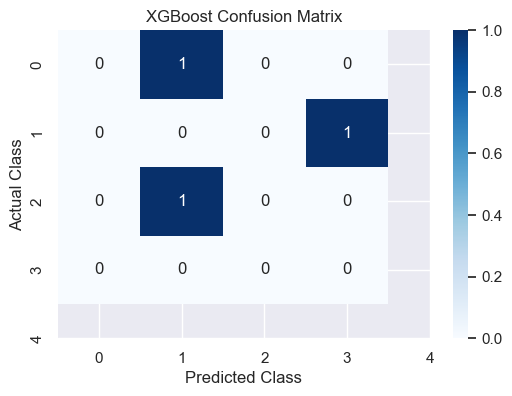

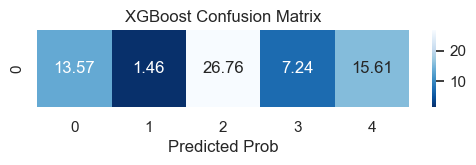

In [64]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(1/pred, annot=True, fmt='.2f', cmap='Blues_r', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Away

In [66]:
target = "GAC"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [67]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [68]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

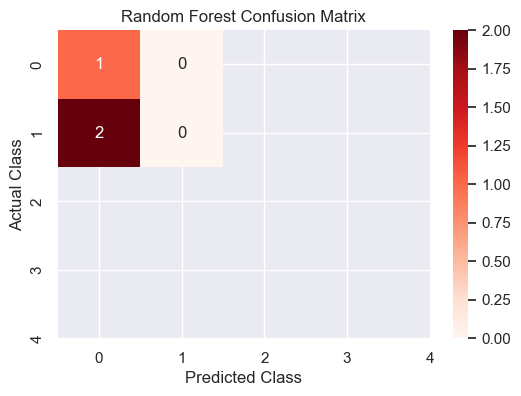

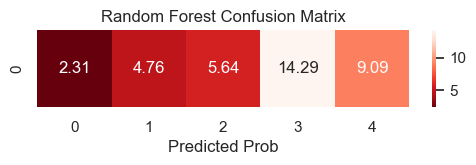

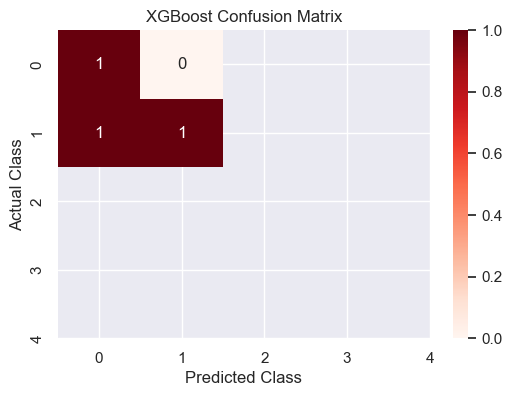

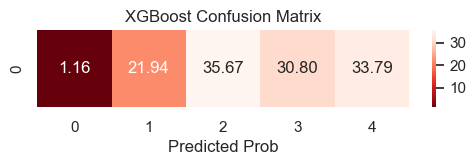

In [70]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(1/pred, annot=True, fmt='.2f', cmap='Reds_r', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

## Regression

### Model Home

In [67]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [68]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [69]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

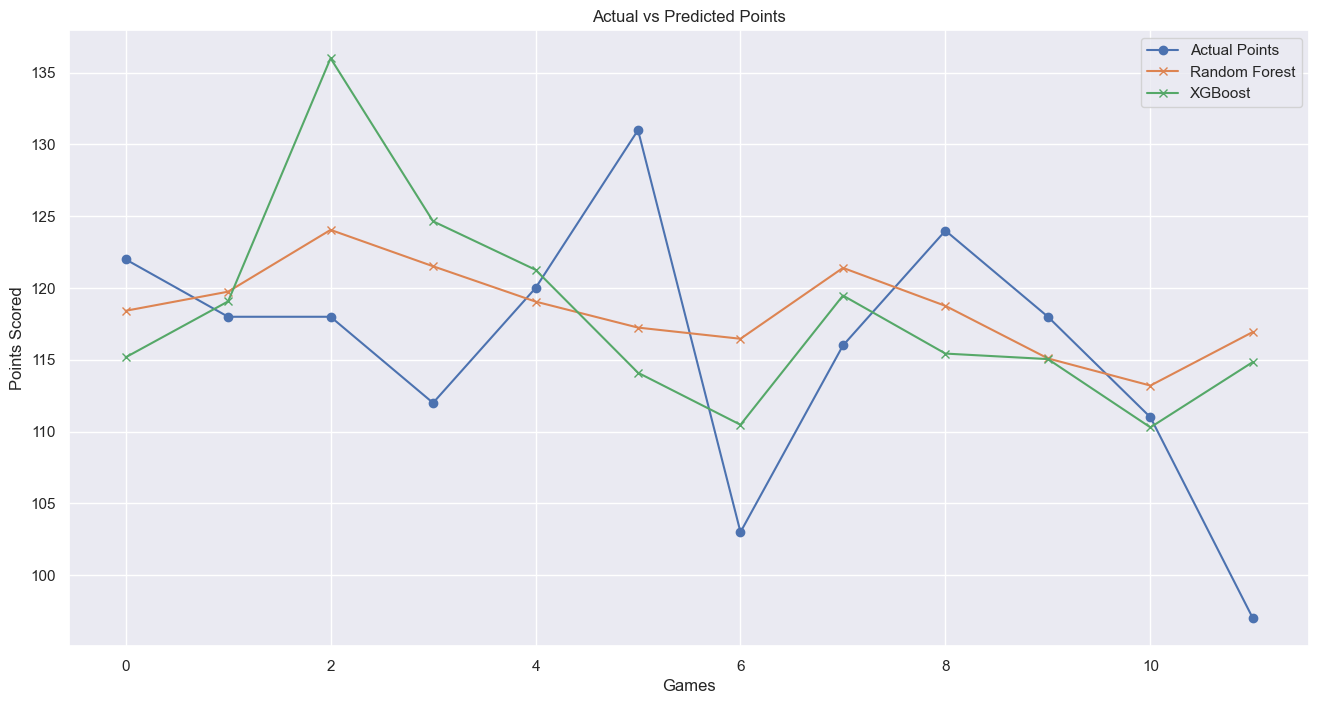

In [85]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

# Split into training and testing sets
train_size = int(len(X) * 0.8)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
# Train and evaluate each model
results = {}
plt.figure(figsize=(16,8))
plt.plot(y_test.values, label='Actual Points', marker='o')
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    plt.plot(y_pred, label=name, marker='x')
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred[0]}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T
plt.legend()
plt.title("Actual vs Predicted Points")
plt.xlabel("Games")
plt.ylabel("Points Scored")
plt.show()

In [80]:
results_df

,MAE,RMSE,PRED
Random Forest,7.063876,9.047376,117.443289
XGBoost,8.145854,10.362132,118.500099


### Model vs Home

In [48]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [49]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [50]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 13.425
RMSE: 14.329


In [52]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000991 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6818
[LightGBM] [Info] Number of data points in the train set: 52, number of used features: 405
[LightGBM] [Info] Start training from score 108.211538
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [53]:
results_df

,MAE,RMSE,PRED
Random Forest,13.041667,13.840622,[108.75]
XGBoost,13.151134,15.03493,[113.32865]
LightGBM,16.852781,18.445559,[102.71760442340414]
Linear Regression,24.528301,25.202121,[84.73789959470245]


### Model Away

In [54]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [55]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 12.708
RMSE: 14.490


In [59]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6654
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 121.941176
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [60]:
results_df

,MAE,RMSE,PRED
Random Forest,14.915,16.475376,[120.74]
XGBoost,12.521159,13.834184,[121.489395]
LightGBM,13.837515,17.031631,[126.221659266553]
Linear Regression,14.006226,16.370987,[137.60611314295068]


### Model vs Away

In [61]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [62]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [63]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 10.350
RMSE: 11.309


In [65]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000408 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6692
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 110.666667
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [66]:
results_df

,MAE,RMSE,PRED
Random Forest,11.596667,12.906048,[108.99]
XGBoost,15.120514,16.820382,[102.5551]
LightGBM,9.838286,11.897321,[109.56588285586935]
Linear Regression,14.973625,19.146221,[86.82162740707135]
